# 01 · Data collection and quality

**Question for the whole project:** what is one race on NY Racing's No. 44 worth to a sponsor on TV, and how likely is the car to be in the race at all?

This notebook covers where the data comes from, how it was cleaned, and the checks that prove it is complete. Everything downstream depends on it.

| Source | What it gives | Rows |
|---|---|---|
| NASCAR loop data feed | average running position, laps led, top-15 laps, passes, driver rating for every starter | 1,369 starts |
| NASCAR weekend results feed | official finish, status, team, sponsor, broadcaster, cautions | 1,375 entries |
| Published Nielsen audiences (Daily Downforce tracker, Wikipedia) | viewers per race | 36 races |

All 36 points races of the 2025 Cup Series are included. Exhibition races (Clash, All-Star, Duels) are not.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from viz import use_style, short_track, money_axis, headline, source, SEQ, FIELD, NY, THIRD, INK, INK_2, CONTEXT
import matplotlib
use_style()
pd.set_option("display.max_columns", 20, "display.width", 140)
ROOT = Path.cwd().parent
con = duckdb.connect(str(ROOT / "data" / "nascar_2025.duckdb"), read_only=True)

## The warehouse

`src/build_db.py` loads the raw per-race CSVs into DuckDB: one file, SQL for analysis, no server. Three tables and one view:

In [2]:
for t in ["races", "entries", "loop", "starters"]:
    n = con.execute(f"SELECT count(*) FROM {t}").fetchone()[0]
    print(f"{t:<9} {n:>5} rows")
con.execute("SELECT race_date, race_name, track_type, broadcaster, cars_in_field, total_laps, cautions FROM races ORDER BY race_date LIMIT 8").df()

races        36 rows
entries    1375 rows
loop       1369 rows
starters   1369 rows


,race_date,race_name,track_type,broadcaster,cars_in_field,total_laps,cautions
0,2025-02-16,DAYTONA 500,superspeedway,FOX,41,201,8
1,2025-02-23,Ambetter Health 400,superspeedway,FOX,39,266,11
2,2025-03-02,EchoPark Automotive Grand Prix,road,FOX,37,95,4
3,2025-03-09,Shriners Children's 500,short,FS1,37,312,10
4,2025-03-16,Pennzoil 400 presented by Jiffy Lube,intermediate,FS1,36,267,9
5,2025-03-23,Straight Talk Wireless 400,intermediate,FS1,37,267,4
6,2025-03-30,Cook Out 400,short,FS1,38,400,10
7,2025-04-06,Goodyear 400,intermediate,FS1,38,297,8


## Source quirks the pipeline handles

Three problems in the feed would silently corrupt joins if ignored:

1. **Post-race penalties.** At spring Martinsville and spring Talladega, official results differ from the on-track finish in the loop data. The pipeline keeps both: `finish` (official) and `track_finish` (on track).
2. **Non-starters.** Cars that failed to qualify or withdrew appear in results with position 0. They stay in `entries` with `started = false`. This is the raw material for the qualification model.
3. **An empty feed.** Fall Talladega's results feed is empty. That race is rebuilt from loop data plus a driver lookup built from the other 35 races.

In [3]:
con.execute('''
    SELECT race_name, driver, team_name, finish AS official_finish, track_finish, status
    FROM starters WHERE race_id IN (5553, 5555) AND finish <> track_finish
    ORDER BY race_id, finish LIMIT 6
''').df()

,race_name,driver,team_name,official_finish,track_finish,status
0,Cook Out 400,Chris Buescher,RFK Racing,24,25,Running
1,Cook Out 400,John H. Nemechek,Legacy Motor Club,25,26,Running
2,Cook Out 400,Brad Keselowski,RFK Racing,26,27,Running
3,Cook Out 400,Alex Bowman,Hendrick Motorsports,27,28,Running
4,Cook Out 400,Justin Haley,Spire Motorsports,28,29,Running
5,Cook Out 400,Noah Gragson,Front Row Motorsports,29,30,Running


In [4]:
con.execute('''
    SELECT r.race_name, e.car_number, e.driver, e.team_name, e.sponsor
    FROM entries e JOIN races r USING (race_id) WHERE NOT e.started ORDER BY r.race_date
''').df()

,race_name,car_number,driver,team_name,sponsor
0,DAYTONA 500,62,Anthony Alfredo,Beard Motorsports,Fortify Building Solutions
1,DAYTONA 500,78,BJ McLeod,Live Fast Motorsports,HitchGo
2,DAYTONA 500,44,JJ Yeley,NY Racing Team,Green River Whiskey
3,DAYTONA 500,66,Chandler Smith,Power Source,QuickTie
4,Grant Park 165,67,Corey Heim,23XI Racing,Robinhood
5,Go Bowling at The Glen,87,Connor Zilisch,Trackhouse Racing,Red Bull


## Data-quality checks

The same checks run as `pytest` in CI. Laps led must sum exactly to the race distance in every race, a strong test that no rows were lost or duplicated.

In [5]:
checks = {
    "36 points races": con.execute("SELECT count(*) = 36 FROM races").fetchone()[0],
    "laps led sum to race distance (all races)": con.execute('''
        SELECT count(*) = 0 FROM (SELECT r.race_id FROM races r JOIN loop l USING (race_id)
        GROUP BY r.race_id, r.total_laps HAVING sum(l.lead_laps) <> r.total_laps)''').fetchone()[0],
    "field size = starters (all races)": con.execute('''
        SELECT count(*) = 0 FROM (SELECT r.race_id FROM races r JOIN loop l USING (race_id)
        GROUP BY r.race_id, r.cars_in_field HAVING count(*) <> r.cars_in_field)''').fetchone()[0],
    "every starter joins to an entry": con.execute("SELECT (SELECT count(*) FROM loop) = (SELECT count(*) FROM starters)").fetchone()[0],
    "No. 44: 15 entries, 14 starts": con.execute("SELECT count(*) = 15 AND sum(started::int) = 14 FROM entries WHERE is_ny_racing").fetchone()[0],
}
pd.Series(checks, name="passed").to_frame()

,passed
36 points races,True
laps led sum to race distance (all races),True
field size = starters (all races),True
every starter joins to an entry,True
"No. 44: 15 entries, 14 starts",True


## Audience per race

Audience is what turns seconds on screen into dollars. It varies by more than 5× across the season, and the biggest numbers are all in FOX's window at the start of the year.

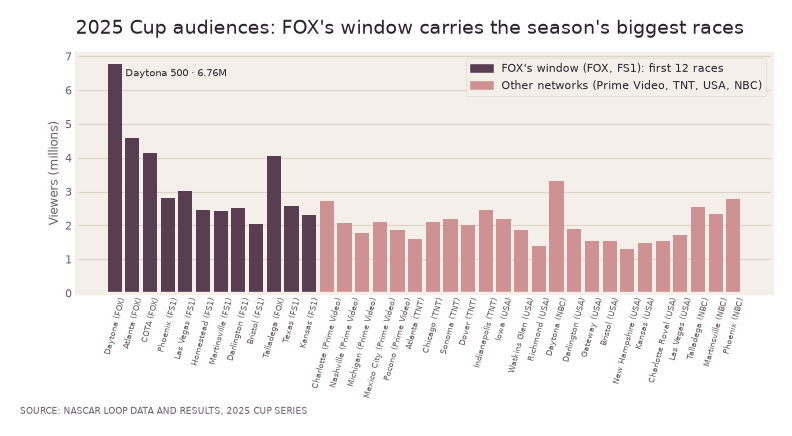

,count,median
broadcaster,,
FOX,4,4.36
NBC,4,2.66
FS1,8,2.49
TNT,5,2.10
PRIME VIDEO,5,2.06
USA,10,1.54


In [6]:
from matplotlib.patches import Patch
views = pd.read_csv(ROOT / "data/raw/viewership_2025.csv")
races = con.execute("SELECT race_id, race_date, track_name, broadcaster FROM races").df().merge(views, on="race_id").sort_values("race_date")
fox = races.broadcaster.isin(["FOX", "FS1"])
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(range(len(races)), races.viewers_m, color=np.where(fox, FIELD, CONTEXT), width=0.8)
ax.set_xticks(range(len(races)), [f"{short_track(t)} ({b.title() if b == 'PRIME VIDEO' else b})" for t, b in zip(races.track_name, races.broadcaster)], rotation=75, fontsize=7)
ax.set_ylabel("Viewers (millions)"); ax.grid(axis="x", visible=False)
headline(fig, "2025 Cup audiences: FOX's window carries the season's biggest races")
ax.legend(handles=[Patch(color=FIELD, label="FOX's window (FOX, FS1): first 12 races"),
                   Patch(color=CONTEXT, label="Other networks (Prime Video, TNT, USA, NBC)")], loc="upper right")
ax.text(0.6, races.viewers_m.max() - 0.35, f"Daytona 500 · {races.viewers_m.max():.2f}M", color=INK, fontsize=9)
source(fig); plt.show()
races.groupby("broadcaster").viewers_m.agg(["count", "median"]).round(2).sort_values("median", ascending=False)

## Who can miss the race

36 cars entered all 36 races: those are the 36 chartered cars, guaranteed a starting spot. Everyone else is an open entry competing for the remaining 4 spots (the field maxes at 40, plus the occasional Open Exemption Provisional). A race is only risky for an open car when more than 4 open cars enter.

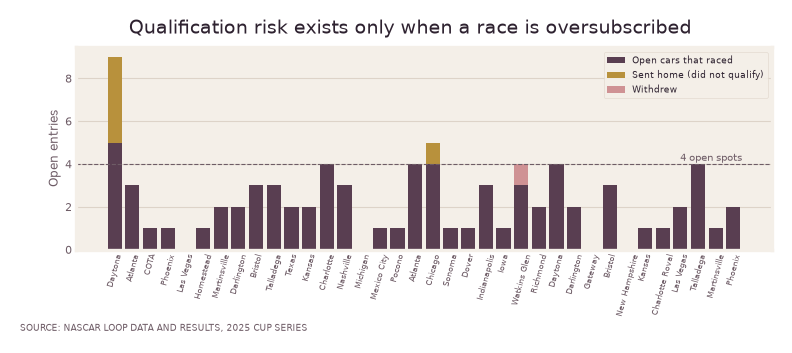

,race_name,open_entries,open_starters,open_non_starters
0,DAYTONA 500,9,5,4
19,Grant Park 165,5,4,1


In [7]:
q = pd.read_csv(ROOT / "data/processed/qualification.csv").merge(races[["race_id", "race_date"]], on="race_id").sort_values("race_date")
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(range(len(q)), q.open_starters, color=FIELD, width=0.8, label="Open cars that raced")
dnq = np.where(q.oversubscribed, q.open_non_starters, 0); wd = np.where(q.oversubscribed, 0, q.open_non_starters)
ax.bar(range(len(q)), dnq, bottom=q.open_starters, color=NY, width=0.8, label="Sent home (did not qualify)")
ax.bar(range(len(q)), wd, bottom=q.open_starters, color=CONTEXT, width=0.8, label="Withdrew")
ax.axhline(4, color=INK_2, lw=1, ls="--"); ax.text(len(q) - 0.5, 4.15, "4 open spots", ha="right", color=INK_2, fontsize=9)
ax.set_xticks(range(len(q)), [short_track(n) for n in q.track_name], rotation=75, fontsize=7)
ax.set_ylabel("Open entries"); ax.grid(axis="x", visible=False); ax.legend(loc="upper right", fontsize=8)
headline(fig, "Qualification risk exists only when a race is oversubscribed")
source(fig); plt.show()
q[q.oversubscribed][["race_name", "open_entries", "open_starters", "open_non_starters"]]

Two races were oversubscribed in 2025. At the Daytona 500, 9 open cars entered and 4 went home, including the No. 44. At the Chicago street race, 5 entered and 1 went home. At the Glen, one open car appears as a non-starter, but only 4 entered: that was a withdrawal, not a DNQ.

**Next:** [02 · Exploratory analysis](02_exploratory_analysis.ipynb)